In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modelos
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [3]:
# Asumiendo que X_final tiene tus 23 features e y es 'critical_temp'
# Si aún no los tienes en memoria, cárgalos:
df_final = pd.read_csv('dataset_final_23features.csv')
X_final = df_final.drop(columns=['critical_temp'])
y = df_final['critical_temp']

# 1. Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

print(f"✓ Datos divididos:")
print(f"  - Train: {X_train.shape[0]} filas")
print(f"  - Test:  {X_test.shape[0]} filas")

# 2. Definir los modelos y sus grillas de búsqueda (ajustadas para ser rápidas pero efectivas)
modelos_y_parametros = {
    "Random Forest": {
        "modelo": RandomForestRegressor(random_state=42),
        "parametros": {
            'modelo__n_estimators': [100, 200, 300],
            'modelo__max_depth': [10, 20, 30, None],
            'modelo__min_samples_split': [2, 5, 10]
        }
    },
    "Gradient Boosting": {
        "modelo": GradientBoostingRegressor(random_state=42),
        "parametros": {
            'modelo__n_estimators': [100, 200],
            'modelo__learning_rate': [0.05, 0.1, 0.2],
            'modelo__max_depth': [3, 5, 7]
        }
    },
    "ElasticNet": {
        "modelo": ElasticNet(random_state=42, max_iter=5000),
        "parametros": {
            'modelo__alpha': [0.01, 0.1, 1.0, 10.0],
            'modelo__l1_ratio': [0.1, 0.5, 0.9]
        }
    },
    "SVR (RBF)": {
        "modelo": SVR(),
        "parametros": {
            'modelo__C': [0.1, 1, 10],
            'modelo__epsilon': [0.01, 0.1, 0.2],
            'modelo__kernel': ['rbf']
        }
    }
}

✓ Datos divididos:
  - Train: 16957 filas
  - Test:  4240 filas


In [4]:
resultados = []
mejores_modelos = {}

print("="*80)
print(" INICIANDO ENTRENAMIENTO Y TUNING DE HIPERPARÁMETROS")
print("="*80)

for nombre, config in modelos_y_parametros.items():
    print(f"\n🚀 Entrenando: {nombre}...")
    inicio = time.time()
    
    # Crear pipeline: Escalado + Modelo
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', config["modelo"])
    ])
    
    # Configurar RandomizedSearchCV
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config["parametros"],
        n_iter=5,              # 15 combinaciones aleatorias por modelo (buen balance velocidad/precisión)
        cv=5,                   # 5-fold cross-validation
        scoring='neg_root_mean_squared_error', # Optimizamos para minimizar RMSE
        random_state=42,
        verbose=0
    )
    
    # Ajustar
    search.fit(X_train, y_train)
    
    # Evaluar en el conjunto de prueba
    y_pred = search.predict(X_test)
    
    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    tiempo = time.time() - inicio
    
    # Guardar resultados
    resultados.append({
        'Modelo': nombre,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Tiempo (s)': round(tiempo, 2),
        'Mejores_Params': search.best_params_
    })
    
    mejores_modelos[nombre] = search.best_estimator_
    print(f"  ✓ Completado en {tiempo:.2f}s | R²: {r2:.4f} | RMSE: {rmse:.4f}")

# Crear DataFrame de resultados
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='R2', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print(" RESUMEN DE RESULTADOS")
print("="*80)
display(df_resultados[['Modelo', 'R2', 'RMSE', 'MAE', 'Tiempo (s)']])

 INICIANDO ENTRENAMIENTO Y TUNING DE HIPERPARÁMETROS

🚀 Entrenando: Random Forest...
  ✓ Completado en 396.61s | R²: 0.9187 | RMSE: 9.7854

🚀 Entrenando: Gradient Boosting...
  ✓ Completado en 182.91s | R²: 0.9110 | RMSE: 10.2342

🚀 Entrenando: ElasticNet...
  ✓ Completado en 0.83s | R²: 0.5984 | RMSE: 21.7422

🚀 Entrenando: SVR (RBF)...
  ✓ Completado en 104.67s | R²: 0.7901 | RMSE: 15.7199

 RESUMEN DE RESULTADOS


,Modelo,R2,RMSE,MAE,Tiempo (s)
0,Random Forest,0.918656,9.785394,5.461200,396.61
1,Gradient Boosting,0.911023,10.234208,6.323713,182.91
2,SVR (RBF),0.790074,15.719853,9.671939,104.67
3,ElasticNet,0.598417,21.742179,17.164658,0.83


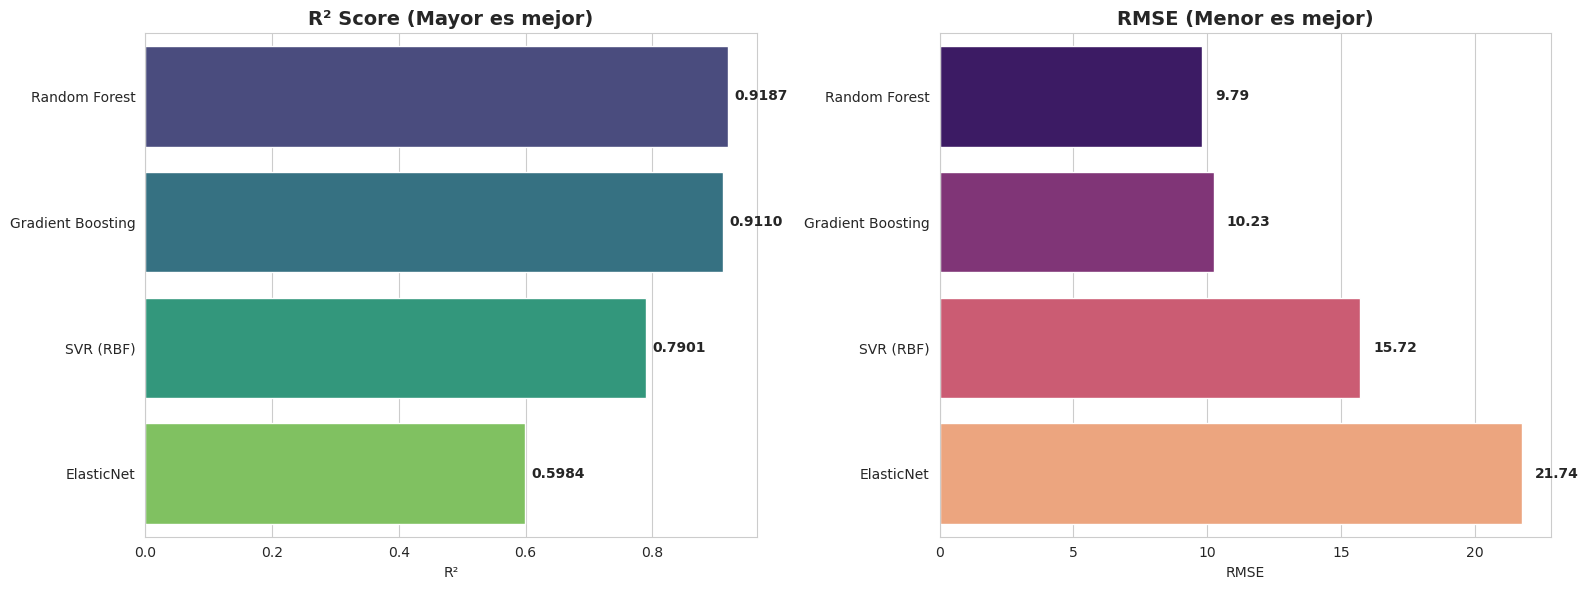

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: R² Score
sns.barplot(data=df_resultados, x='R2', y='Modelo', ax=axes[0], palette='viridis')
axes[0].set_title('R² Score (Mayor es mejor)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].set_ylabel('')
for i, v in enumerate(df_resultados['R2']):
    axes[0].text(v + 0.01, i, f"{v:.4f}", va='center', fontweight='bold')

# Gráfico 2: RMSE
sns.barplot(data=df_resultados, x='RMSE', y='Modelo', ax=axes[1], palette='magma')
axes[1].set_title('RMSE (Menor es mejor)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('')
for i, v in enumerate(df_resultados['RMSE']):
    axes[1].text(v + 0.5, i, f"{v:.2f}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Identificar el mejor modelo según R²
mejor_modelo_nombre = df_resultados.iloc[0]['Modelo']
mejor_pipeline = mejores_modelos[mejor_modelo_nombre]

print(f"🏆 MEJOR MODELO: {mejor_modelo_nombre}")
print(f"   Hiperparámetros: {df_resultados.iloc[0]['Mejores_Params']}")
print(f"   R² en Test: {df_resultados.iloc[0]['R2']:.4f}")

# Opcional: Guardar el modelo con joblib para usarlo después sin reentrenar
import joblib
joblib.dump(mejor_pipeline, 'mejor_modelo_regresion.pkl')
joblib.dump(df_resultados, 'resultados_comparacion_modelos.pkl')

print("\n✓ Mejor modelo y resultados guardados exitosamente.")

🏆 MEJOR MODELO: Random Forest
   Hiperparámetros: {'modelo__n_estimators': 100, 'modelo__min_samples_split': 5, 'modelo__max_depth': None}
   R² en Test: 0.9187

✓ Mejor modelo y resultados guardados exitosamente.


In [7]:
import joblib
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import PartialDependenceDisplay
from scipy.optimize import differential_evolution

# 1. Guardar el modelo Gradient Boosting
modelo_gb = mejores_modelos['Gradient Boosting']
joblib.dump(modelo_gb, 'modelo_gradient_boosting_final.pkl')
print("✓ Modelo Gradient Boosting guardado como 'modelo_gradient_boosting_final.pkl'")

# 2. Preparar SHAP (Explicabilidad del modelo)
# Nota: SHAP con Gradient Boosting de sklearn es rápido, pero usaremos un subconjunto del test para agilizar los gráficos
X_test_sample = shap.sample(X_test, 100) # 100 instancias representativas

print("Calculando valores SHAP (esto puede tomar ~30 segundos)...")
explainer = shap.TreeExplainer(modelo_gb.named_steps['modelo'])
shap_values = explainer.shap_values(X_test_sample)

print("✓ Cálculo de SHAP completado.")

✓ Modelo Gradient Boosting guardado como 'modelo_gradient_boosting_final.pkl'
Calculando valores SHAP (esto puede tomar ~30 segundos)...
✓ Cálculo de SHAP completado.


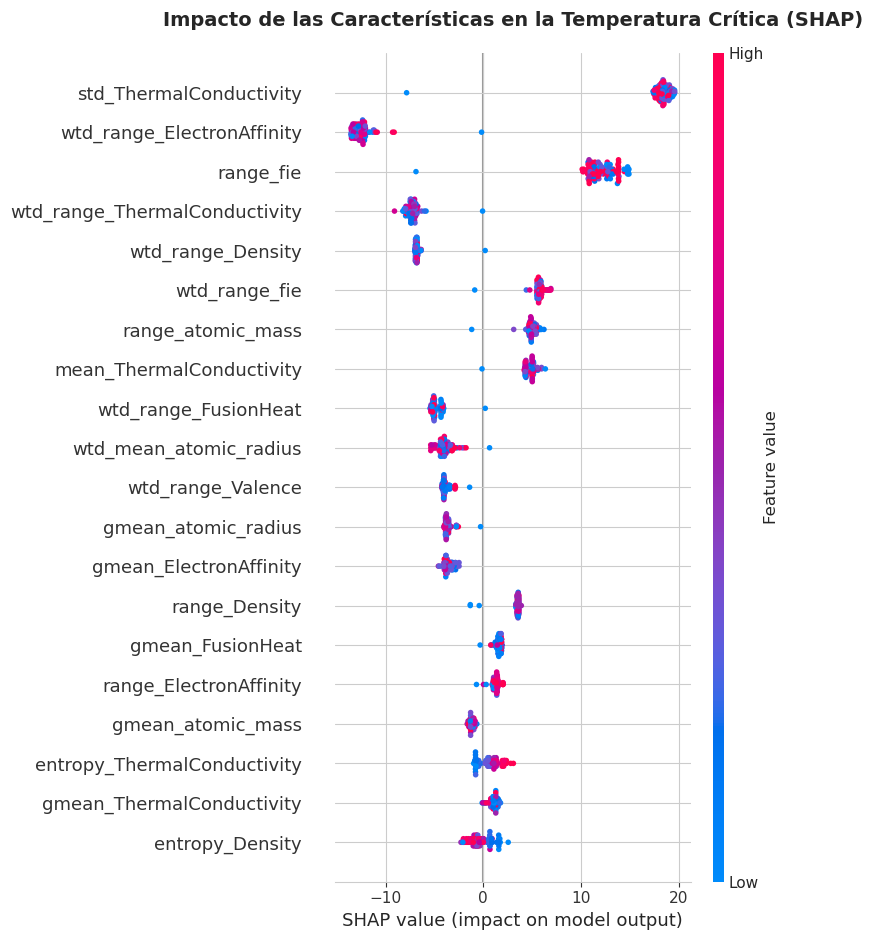

In [8]:
# Este gráfico muestra qué características aumentan (rojo) o disminuyen (azul) la Tc
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test_sample, 
    feature_names=X_test_sample.columns,
    show=False
)
plt.title('Impacto de las Características en la Temperatura Crítica (SHAP)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

Generando gráficos de dependencia parcial para: ['range_fie', 'range_ElectronAffinity', 'std_ThermalConductivity', 'range_Density']


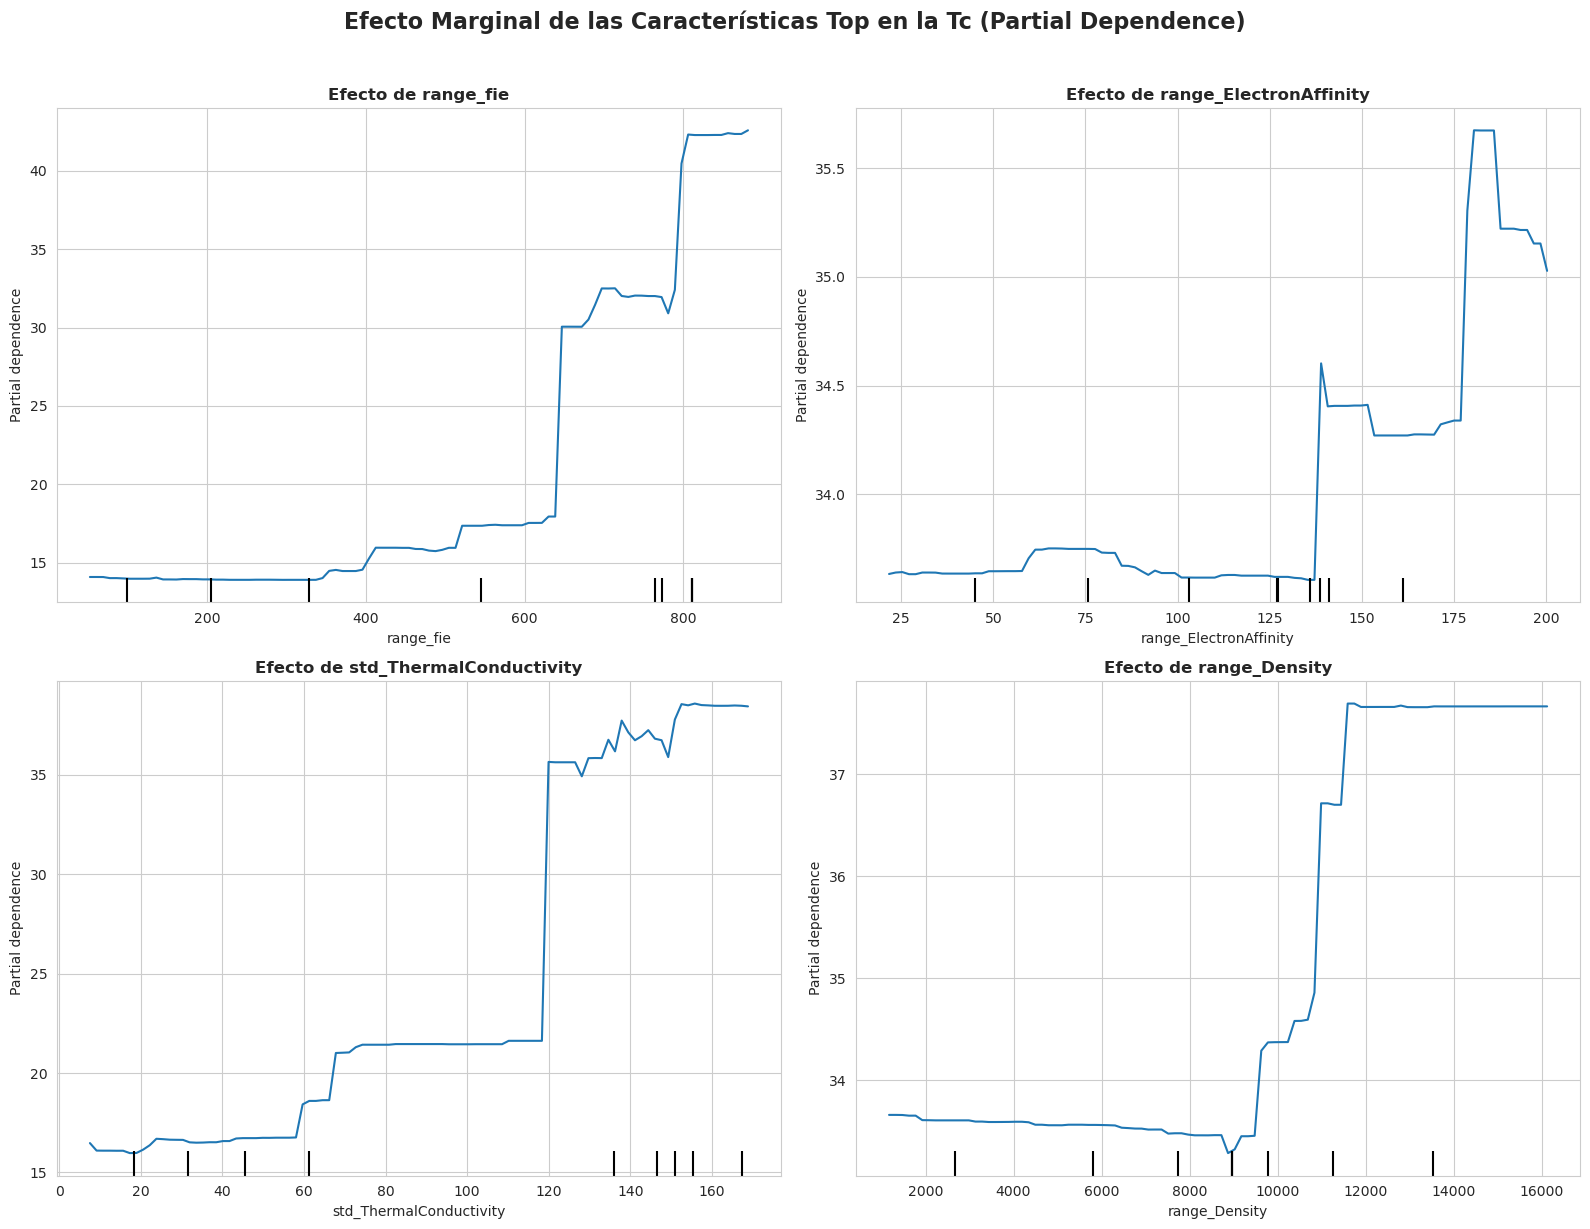

In [9]:
# Seleccionamos las 4 características más importantes según SHAP
# (Ajusta estos nombres si tu lista de 23 features tiene nombres ligeramente distintos)
top_features = X_test_sample.columns[:4].tolist() 

print(f"Generando gráficos de dependencia parcial para: {top_features}")

fig, ax = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Efecto Marginal de las Características Top en la Tc (Partial Dependence)', 
             fontsize=16, fontweight='bold', y=1.02)

# El modelo en el pipeline está en el paso 'modelo'
gb_model = modelo_gb.named_steps['modelo']

for i, feature in enumerate(top_features):
    row = i // 2
    col = i % 2
    
    # Calcular y graficar
    PartialDependenceDisplay.from_estimator(
        modelo_gb, # Usamos el pipeline completo para que escale automáticamente
        X_test, 
        features=[feature], 
        ax=ax[row, col],
        kind='average'
    )
    ax[row, col].set_title(f'Efecto de {feature}', fontsize=12, fontweight='bold')
    ax[row, col].set_ylabel('Temperatura Crítica Predicha (K)', fontsize=10)

plt.tight_layout()
plt.savefig('pdp_top_features.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
print("="*80)
print(" BÚSQUEDA DEL MATERIAL IDEAL PARA TEMPERATURA AMBIENTE (~300 K)")
print("="*80)

# 1. Definir los límites de búsqueda basados en los datos de entrenamiento
# (Para no pedirle al modelo que extrapole a valores físicamente imposibles)
bounds = []
for col in X_train.columns:
    min_val = X_train[col].min() * 0.9  # 10% de margen por debajo del mínimo observado
    max_val = X_train[col].max() * 1.1  # 10% de margen por encima del máximo observado
    bounds.append((min_val, max_val))

# 2. Función objetivo: Queremos MAXIMIZAR la predicción, por lo que minimizamos su negativo
def objetivo(x):
    # x es un array 1D, el modelo espera 2D
    x_2d = x.reshape(1, -1)
    prediccion = modelo_gb.predict(x_2d)[0]
    return -prediccion # Negativo porque differential_evolution minimiza

# 3. Ejecutar optimización global (Algoritmo de Evolución Diferencial, muy robusto para árboles)
print("Ejecutando optimización (puede tomar 1-2 minutos)...")
resultado_opt = differential_evolution(
    objetivo, 
    bounds, 
    seed=42, 
    maxiter=500, 
    popsize=15, 
    tol=0.01,
    polish=True
)

# 4. Extraer y mostrar los resultados
mejores_caracteristicas = resultado_opt.x
tc_predicha = -resultado_opt.fun

print(f"\n🏆 RESULTADO DE LA OPTIMIZACIÓN:")
print(f"  → Temperatura Crítica Predicha: {tc_predicha:.2f} K ({tc_predicha - 273.15:.2f} °C)")

if tc_predicha >= 293:
    print("  → ¡ÉXITO! El modelo predice un superconductor a TEMPERATURA AMBIENTE.")
else:
    print(f"  → El modelo sugiere que, dentro de los límites físicos observados, el máximo teórico es {tc_predicha:.2f} K.")

print("\n  → Características ideales sugeridas por el modelo:")
df_ideal = pd.DataFrame({
    'Característica': X_train.columns,
    'Valor_Optimo': mejores_caracteristicas,
    'Min_Entrenamiento': [b[0] for b in bounds],
    'Max_Entrenamiento': [b[1] for b in bounds]
})

# Mostrar solo las top 10 más importantes para no saturar
display(df_ideal.head(10))

# Guardar este hallazgo
df_ideal.to_csv('caracteristicas_material_ideal_300K.csv', index=False)
print("\n✓ Resultados de optimización guardados en 'caracteristicas_material_ideal_300K.csv'")

 BÚSQUEDA DEL MATERIAL IDEAL PARA TEMPERATURA AMBIENTE (~300 K)
Ejecutando optimización (puede tomar 1-2 minutos)...

🏆 RESULTADO DE LA OPTIMIZACIÓN:
  → Temperatura Crítica Predicha: 178.62 K (-94.53 °C)
  → El modelo sugiere que, dentro de los límites físicos observados, el máximo teórico es 178.62 K.

  → Características ideales sugeridas por el modelo:


,Característica,Valor_Optimo,Min_Entrenamiento,Max_Entrenamiento
0,range_fie,1271.402563,0.000000,1434.950000
1,range_ElectronAffinity,240.035938,0.000000,383.900000
2,std_ThermalConductivity,163.467604,0.000000,236.484765
3,range_Density,16009.387593,0.000000,24847.428100
4,entropy_Density,1.265539,0.000000,2.149726
5,mean_ThermalConductivity,108.377922,0.023922,365.750000
6,gmean_FusionHeat,50.703317,0.199800,115.500000
7,range_atomic_mass,203.989463,0.000000,228.769706
8,gmean_ThermalConductivity,246.805567,0.023922,349.671989
9,range_FusionHeat,64.132749,0.000000,115.255800



✓ Resultados de optimización guardados en 'caracteristicas_material_ideal_300K.csv'
